In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
zip_file_path = "/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Workshop4/Copy of devnagari digit.zip"
extract_path = "/content/"


!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted '{zip_file_path}' to '{extract_path}'.")

replace /content/DevanagariHandwrittenDigitDataset/Test/digit_0/103277.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/DevanagariHandwrittenDigitDataset/Test/digit_0/103281.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/DevanagariHandwrittenDigitDataset/Test/digit_0/103309.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
Successfully extracted '/content/drive/MyDrive/Artificial Intelligence and Machine Learning/Workshop4/Copy of devnagari digit.zip' to '/content/'.


In [50]:
import os
import numpy as np
from PIL import Image

def one_hot_encode(labels, num_classes):
    return np.eye(num_classes)[labels]

In [51]:
def load_dataset(folder_path, img_size=(28, 28)):
    images = []
    labels = []
    class_names = []

    classes = sorted(os.listdir(folder_path))

    for label, class_name in enumerate(classes):
        class_path = os.path.join(folder_path, class_name)

        if os.path.isdir(class_path):
            class_names.append(class_name)

            for file in os.listdir(class_path):
                img_path = os.path.join(class_path, file)
                try:
                    img = Image.open(img_path).convert("RGB")
                    img = img.resize(img_size)
                    img_array = np.array(img) / 255.0
                    images.append(img_array)
                    labels.append(label)
                except:
                    continue

    return np.array(images), np.array(labels), class_names

In [52]:

train_path = "/content/DevanagariHandwrittenDigitDataset/Train"

X_train, y_train, class_names = load_dataset(train_path)

y_train_encoded = one_hot_encode(y_train, len(class_names))

import random
indices = np.arange(len(X_train))
np.random.shuffle(indices)
X_train = X_train[indices]
y_train_encoded = y_train_encoded[indices]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_encoded.shape)
print("Classes:", class_names)

X_train shape: (17000, 28, 28, 3)
y_train shape: (17000, 10)
Classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']


In [53]:

test_path = "/content/DevanagariHandwrittenDigitDataset/Test"

X_test, y_test, _ = load_dataset(test_path)

y_test_encoded = one_hot_encode(y_test, len(class_names))

indices = np.arange(len(X_test))
np.random.shuffle(indices)
X_test = X_test[indices]
y_test_encoded = y_test_encoded[indices]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test_encoded.shape)

X_test shape: (3000, 28, 28, 3)
y_test shape: (3000, 10)


In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(28, 28, 3)),

    Dense(64, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),

    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │       150,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,506 (759.79 KB)

 Trainable params: 194,506 (759.79 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

history = model.fit(
    X_train,
    y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3217 - loss: 2.0635

107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5390 - loss: 1.6354 - val_accuracy: 0.8329 - val_loss: 0.7593
Epoch 2/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8430 - loss: 0.6136

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8571 - loss: 0.5045 - val_accuracy: 0.8876 - val_loss: 0.3524
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9185 - loss: 0.3126

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9271 - loss: 0.2816 - val_accuracy: 0.9421 - val_loss: 0.2238
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9521 - loss: 0.1997

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9543 - loss: 0.1827 - val_accuracy: 0.9518 - val_loss: 0.1747
Epoch 5/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9632 - loss: 0.1396

...

107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9962 - loss: 0.0226 - val_accuracy: 0.9771 - val_loss: 0.0823
Epoch 13/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9983 - loss: 0.0170 - val_accuracy: 0.9744 - val_loss: 0.0872
Epoch 14/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9979 - loss: 0.0152

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9983 - loss: 0.0148 - val_accuracy: 0.9768 - val_loss: 0.0790
Epoch 15/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9992 - loss: 0.0108 - val_accuracy: 0.9776 - val_loss: 0.0807
Epoch 16/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0075

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9995 - loss: 0.0082 - val_accuracy: 0.9779 - val_loss: 0.0773
Epoch 17/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0063

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9996 - loss: 0.0068 - val_accuracy: 0.9803 - val_loss: 0.0771
Epoch 18/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9998 - loss: 0.0053

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9997 - loss: 0.0054 - val_accuracy: 0.9785 - val_loss: 0.0765
Epoch 19/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9999 - loss: 0.0044 - val_accuracy: 0.9791 - val_loss: 0.0773
Epoch 20/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9999 - loss: 0.0036 - val_accuracy: 0.9794 - val_loss: 0.0770


In [44]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_encoded)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6530 - loss: 1.9453
Test Loss: 1.9452508687973022
Test Accuracy: 0.652999997138977


In [45]:
model.save("final_model.keras")

In [46]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [47]:
loss, acc = loaded_model.evaluate(X_test, y_test_encoded)

print("Loaded Model Accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6530 - loss: 1.9453
Loaded Model Accuracy: 0.652999997138977


In [ ]:
predictions = loaded_model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

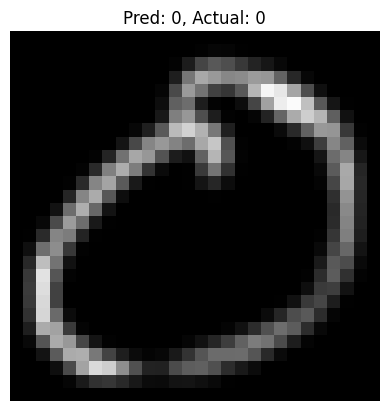

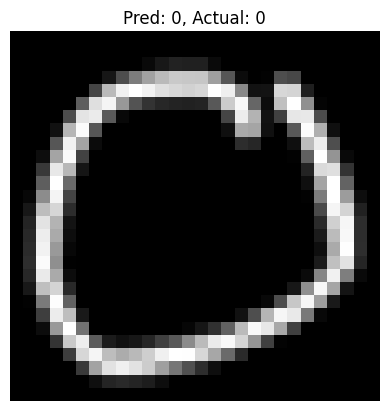

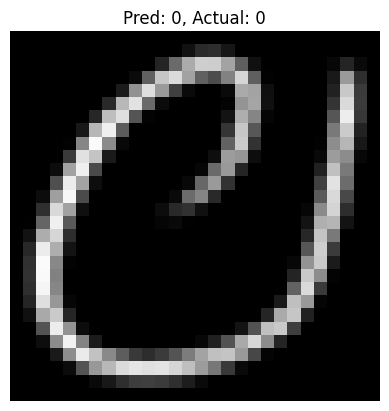

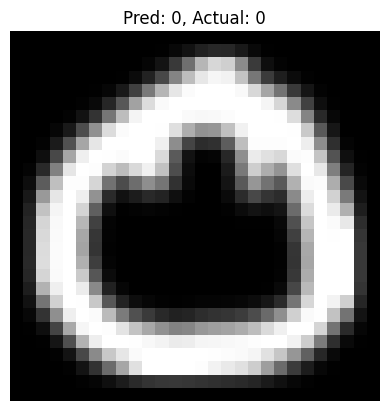

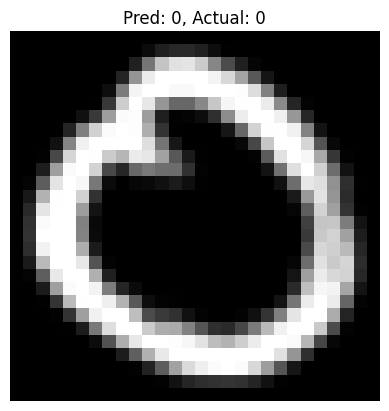

In [ ]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(X_test[i])
    plt.title(f"Pred: {predicted_labels[i]}, Actual: {true_labels[i]}")
    plt.axis("off")
    plt.show()